In [8]:
# ==========================================
# Week 5 – Machine Learning
# Linear Regression Implementation
# ==========================================

# -----------------------------
# 1. Import Libraries
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# -----------------------------
# 2. Dataset Preparation
# -----------------------------
# Create a synthetic dataset
np.random.seed(42)
X = 2 * np.random.rand(100, 1)           # Feature
y = 4 + 3 * X + np.random.randn(100, 1)  # Target with some noise

# Split dataset manually (80% train, 20% test)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [10]:
# -----------------------------
# 3. Mean Squared Error Function
# -----------------------------
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


In [11]:
# -----------------------------
# 4. Linear Regression – Normal Equation
# -----------------------------
class LinearRegressionScratch:
    def __init__(self):
        self.theta = None  # weights (bias + slope)

    def fit(self, X, y):
        # Add bias term (column of ones)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        # Normal Equation: θ = (X^T X)^-1 X^T y
        self.theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

    def predict(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b.dot(self.theta)

# Train Normal Equation model
model_scratch = LinearRegressionScratch()
model_scratch.fit(X_train, y_train)
y_pred_scratch = model_scratch.predict(X_test)

print("Normal Equation Weights (theta):", model_scratch.theta)
print("Normal Equation MSE:", mean_squared_error(y_test, y_pred_scratch))

Normal Equation Weights (theta): [[4.23413762]
 [2.68403623]]
Normal Equation MSE: 0.9755437477937203


In [12]:
# -----------------------------
# 5. Linear Regression – Gradient Descent
# -----------------------------
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.theta = None

    def fit(self, X, y):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]  # Add bias term
        m = X_b.shape[0]
        self.theta = np.zeros((X_b.shape[1], 1))  # initialize weights

        for i in range(self.n_iterations):
            gradients = 2/m * X_b.T.dot(X_b.dot(self.theta) - y)
            self.theta -= self.learning_rate * gradients

    def predict(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b.dot(self.theta)

# Train Gradient Descent model
model_gd = LinearRegressionGD(learning_rate=0.1, n_iterations=1000)
model_gd.fit(X_train, y_train)
y_pred_gd = model_gd.predict(X_test)

print("Gradient Descent Weights (theta):", model_gd.theta)
print("Gradient Descent MSE:", mean_squared_error(y_test, y_pred_gd))

Gradient Descent Weights (theta): [[4.23413762]
 [2.68403623]]
Gradient Descent MSE: 0.9755437477937183


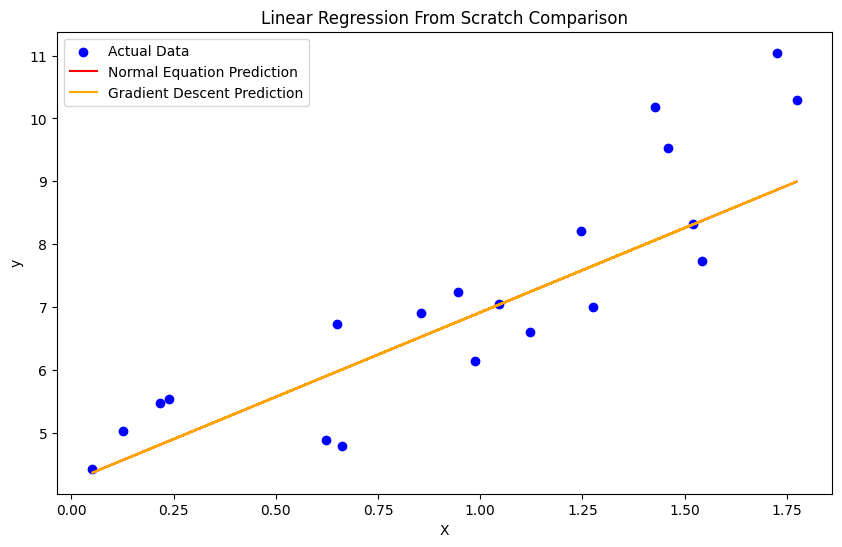

In [13]:
# -----------------------------
# 6. Visualization
# -----------------------------
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred_scratch, color='red', label='Normal Equation Prediction')
plt.plot(X_test, y_pred_gd, color='orange', label='Gradient Descent Prediction')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression From Scratch Comparison')
plt.legend()
plt.show()